In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install paddleocr
!pip install paddlepaddle
!pip install paddleocr paddlepaddle matplotlib opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.7/544.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.9/161.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.2/912.2 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.2 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=d373ec9d36ad6c680869aafef0c9c65c27c68b0bc669f15ade8fe92bb2ebc359
  Stored in directory: /root/.cache/pip/wheels/19/39/2f/2d3cadc408a8804103f1c34ddd4b9f6a93497b11fa96fe738e
Successfully built fire
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.19
    Uninstalling albucore-0.0.19:
   

In [ ]:
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

# CLAHE, Otsu - Sauvola thresholding, dilation, image blending, unsharp masking

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage.filters import threshold_sauvola

# Input and output directories
input_dir = "/content/drive/MyDrive/IAMForms/data"
output_dir = "/content/drive/MyDrive/IAMForms/final"
os.makedirs(output_dir, exist_ok=True)

# List all files in the input directory
image_files = [f for f in os.listdir(input_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.tif'))]

# Process each image
for idx, image_file in enumerate(image_files):
    input_path = os.path.join(input_dir, image_file)

    # Read the image in grayscale
    image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)

    # Step 1: Apply CLAHE (with conservative parameters)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    clahe_output = clahe.apply(image)

    # Step 2: Apply Otsu thresholding globally to preprocess the image
    _, otsu_preprocessed = cv2.threshold(clahe_output, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Step 3: Apply Sauvola thresholding on the Otsu-preprocessed image
    window_size = 25
    sauvola_thresh = threshold_sauvola(otsu_preprocessed, window_size=window_size, k=0.2)
    sauvola_binary = (otsu_preprocessed > sauvola_thresh * 255).astype(np.uint8) * 255

    # Step 4: Enhance strokes using dilation (with a very small kernel)
    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    dilated_image = cv2.dilate(sauvola_binary, kernel_dilate, iterations=1)

    # Step 5: Combine the original and enhanced image using blending
    blended_image = cv2.addWeighted(clahe_output, 0.7, dilated_image, 0.3, 0)

    # Step 6: Apply Unsharp Masking for clarity
    gaussian_blur = cv2.GaussianBlur(blended_image, (5, 5), 0)
    final_image = cv2.addWeighted(blended_image, 1.5, gaussian_blur, -0.5, 0)

    # Save the final enhanced image
    output_path = os.path.join(output_dir, f"final_{idx + 1}.png")
    cv2.imwrite(output_path, final_image)

    # Optionally display the final image
    plt.figure(figsize=(10, 7))
    plt.imshow(final_image, cmap=plt.cm.gray)
    plt.title(f'Enhanced Text Image {idx + 1}')
    plt.axis('off')
    plt.show()

print(f"All processed images are saved in: {output_dir}")


Output hidden; open in https://colab.research.google.com to view.

Total images processed: 8
Denoised images saved to: /content/drive/MyDrive/IAMForms/cleandata


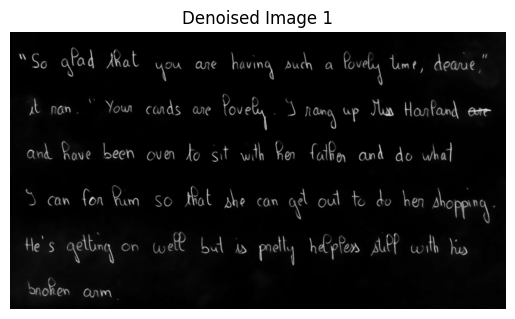

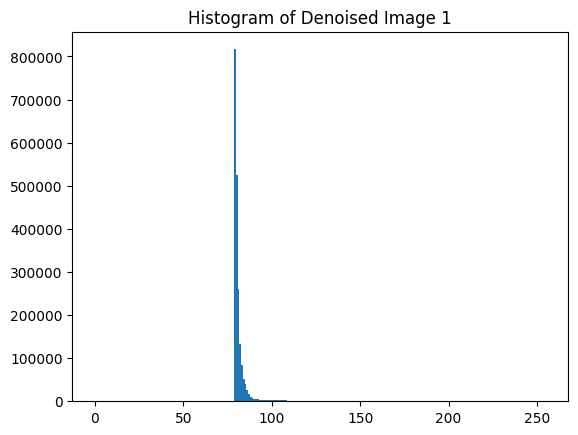

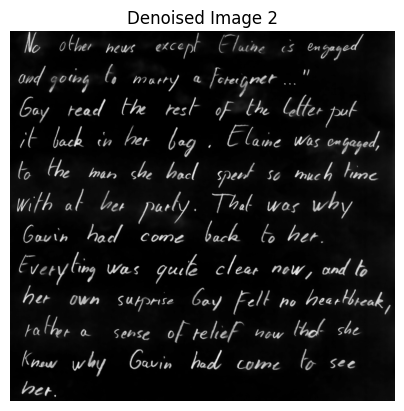

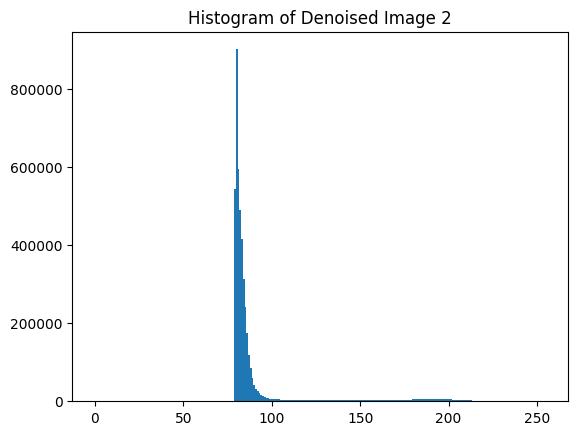

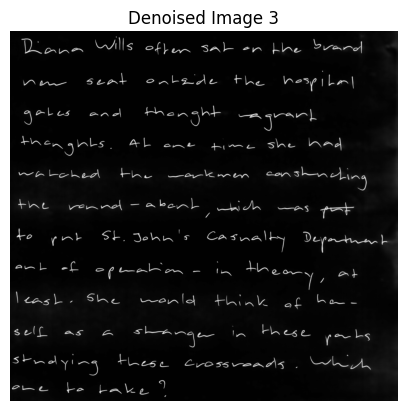

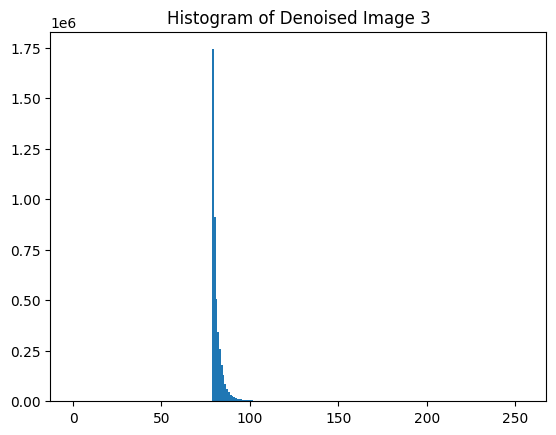

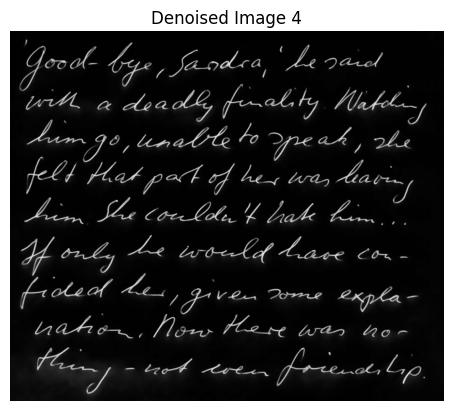

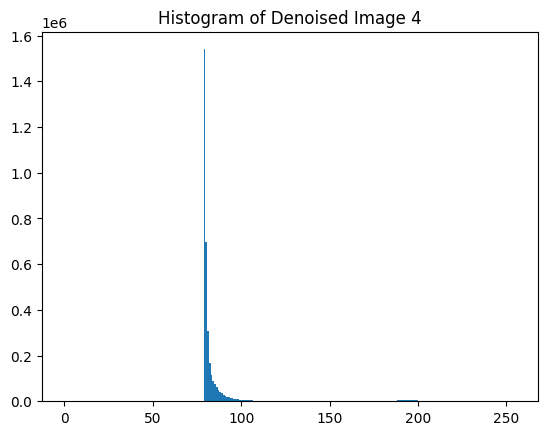

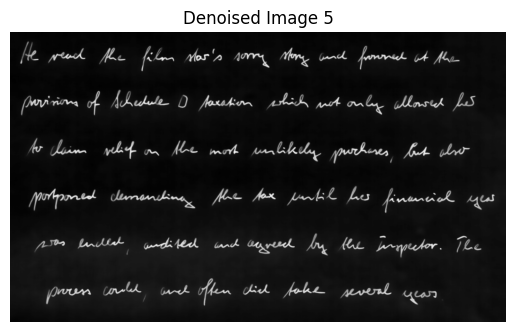

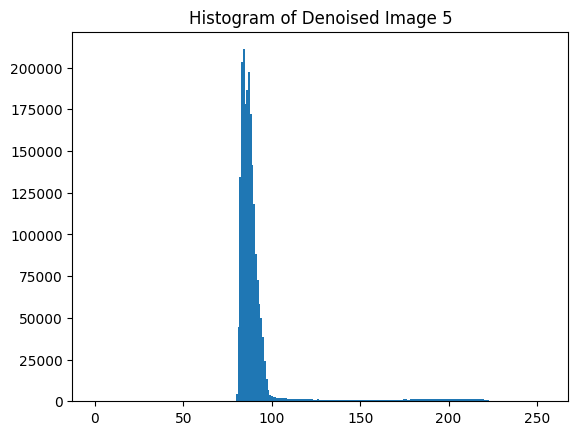

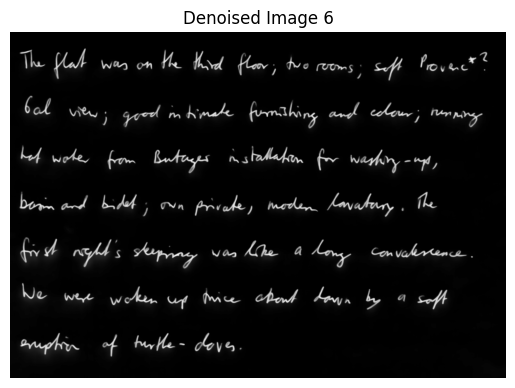

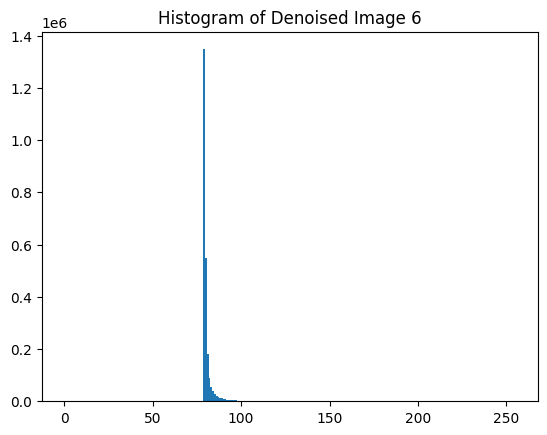

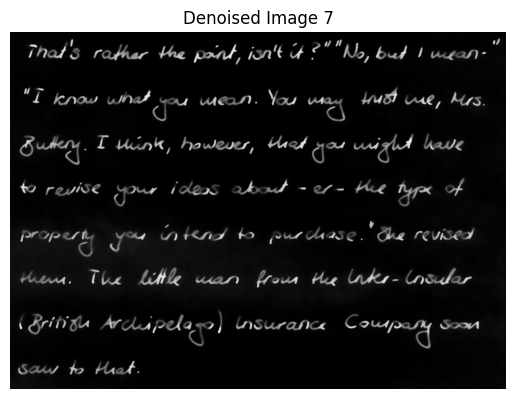

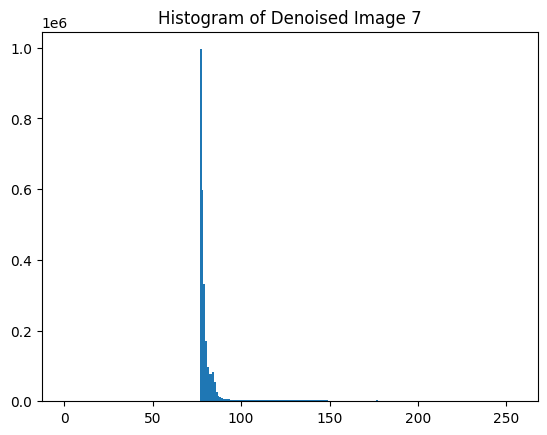

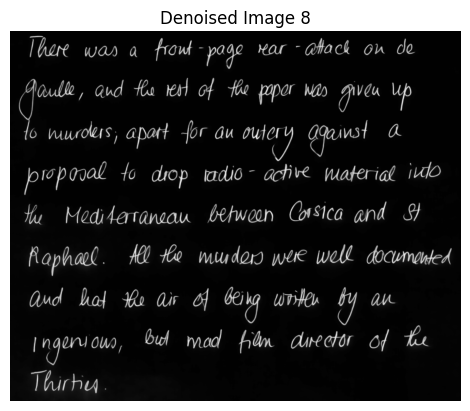

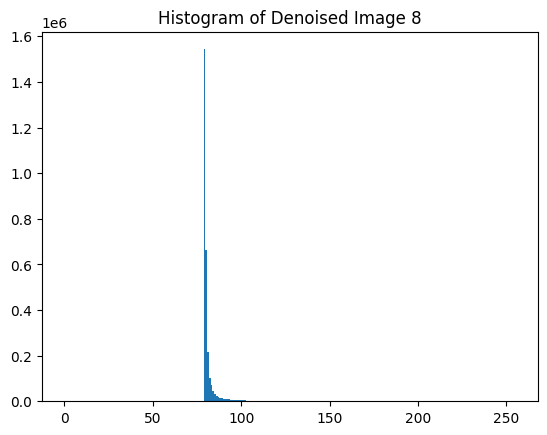

In [ ]:
import os
from PIL import Image
from numpy import asarray
import matplotlib.pyplot as plt
import numpy as np
import cv2  # Import OpenCV for denoising

# Input and output paths
input_path = "/content/drive/MyDrive/IAMForms/final"
output_path = "/content/drive/MyDrive/IAMForms/cleandata"
os.makedirs(output_path, exist_ok=True)  # Create output directory if it doesn't exist

images = []
count = 0

# Denoising function using OpenCV
def denoise_image(image, h=30, templateWindowSize=7, searchWindowSize=21):
    """
    Apply Non-Local Means Denoising to the image using OpenCV.

    Args:
        image (np.ndarray): Input grayscale image as a NumPy array.
        h (int, optional): Filter strength for noise removal. Higher value removes more noise.
        templateWindowSize (int, optional): Size of the template patch used for denoising (odd, greater than 1).
        searchWindowSize (int, optional): Size of the window used to search for patches (odd, greater than 1).

    Returns:
        np.ndarray: Denoised image as a NumPy array.

    Raises:
        ValueError: If the input image is not a 2D array (grayscale).
    """
    if not isinstance(image, np.ndarray):
        raise ValueError("Input image must be a NumPy array.")
    if len(image.shape) != 2:
        raise ValueError("Input image must be a grayscale image (2D array).")
    if templateWindowSize % 2 == 0 or templateWindowSize <= 1:
        raise ValueError("templateWindowSize must be an odd number greater than 1.")
    if searchWindowSize % 2 == 0 or searchWindowSize <= 1:
        raise ValueError("searchWindowSize must be an odd number greater than 1.")

    try:
        denoised = cv2.fastNlMeansDenoising(
            src=image,
            h=h,
            templateWindowSize=templateWindowSize,
            searchWindowSize=searchWindowSize
        )
        return denoised
    except Exception as e:
        raise RuntimeError(f"An error occurred during denoising: {e}")


# Process each image in the input directory
for filename in os.listdir(input_path):
    input_file_path = os.path.join(input_path, filename)
    if not filename.endswith(('.png', '.jpg', '.jpeg', '.tif')):
        continue  # Skip files that are not images

    im = Image.open(input_file_path)
    # Convert the image to a NumPy array
    np_img = asarray(im)

    # Check if the image is grayscale or RGB
    if len(np_img.shape) == 3:  # RGB image
        np_img = np_img[:, :, 0]  # Extract the red channel
    elif len(np_img.shape) == 2:  # Grayscale image
        np_img = np_img  # No need to extract a channel

    # Invert the image
    np_img = 255 - np_img
    np_img = np_img.astype(np.uint8)

    # Apply denoising
    denoised_img = denoise_image(np_img)

    # Append the denoised image to the list
    images.append(denoised_img)

    # Save the denoised image to the output directory
    output_file_path = os.path.join(output_path, f"denoised_{filename}")
    Image.fromarray(denoised_img).save(output_file_path)

    count += 1

print(f"Total images processed: {count}")
print(f"Denoised images saved to: {output_path}")

# Optionally, display the denoised images and their histograms
for i in range(count):
    # Display the denoised image
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Denoised Image {i+1}")
    plt.axis('off')
    plt.show()

    # Display the histogram
    plt.hist(images[i].ravel(), bins=256, range=(0, 255))
    plt.title(f"Histogram of Denoised Image {i+1}")
    plt.show()


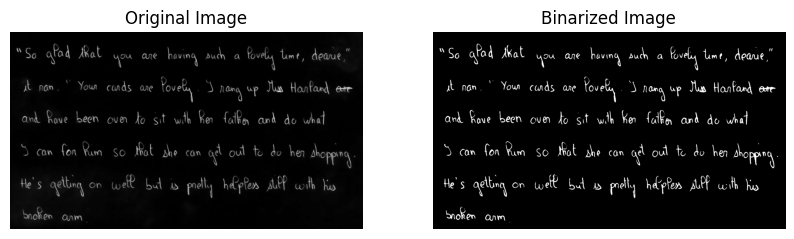

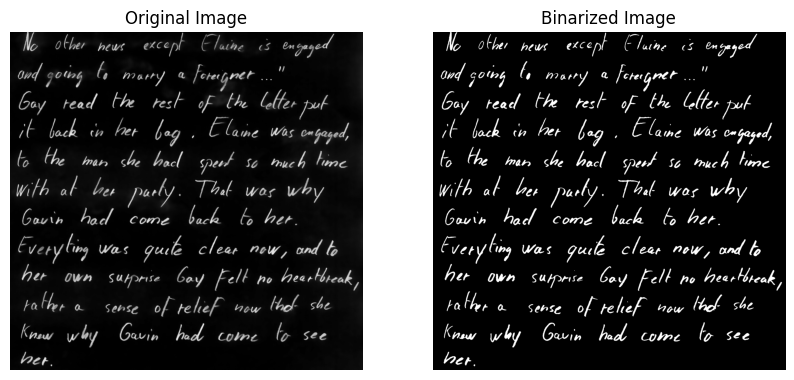

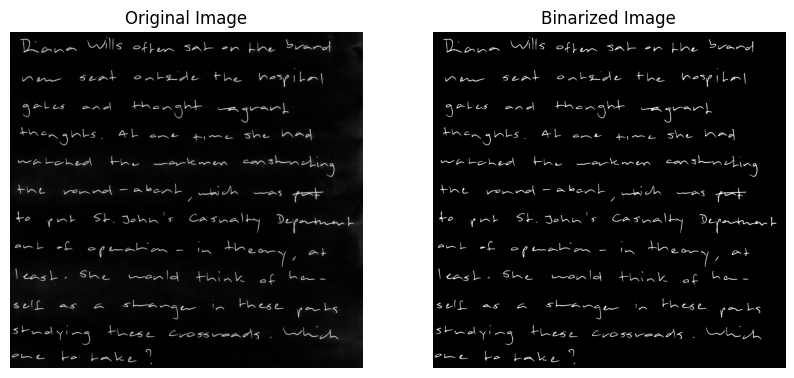

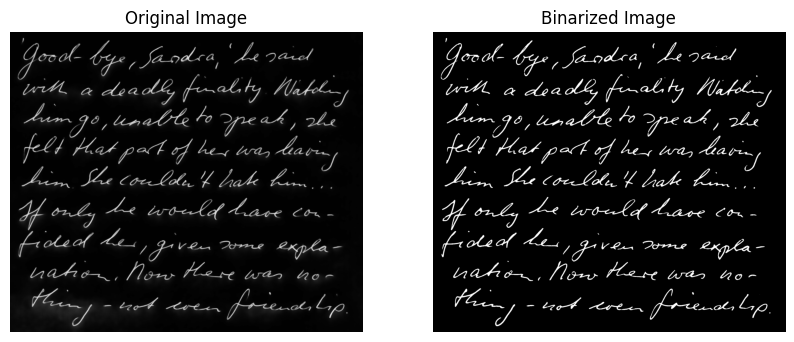

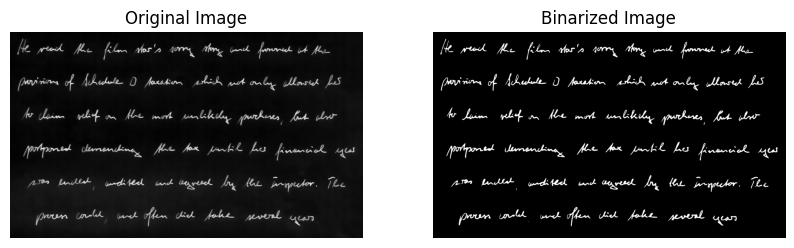

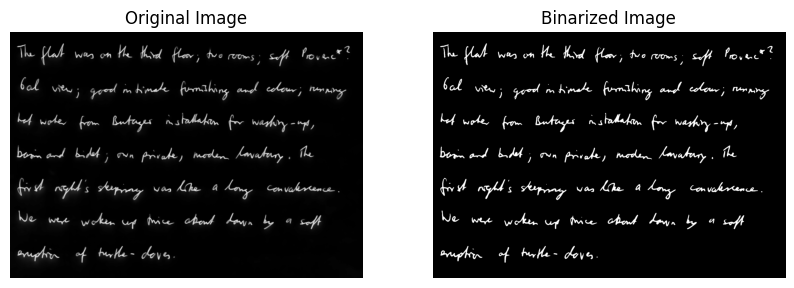

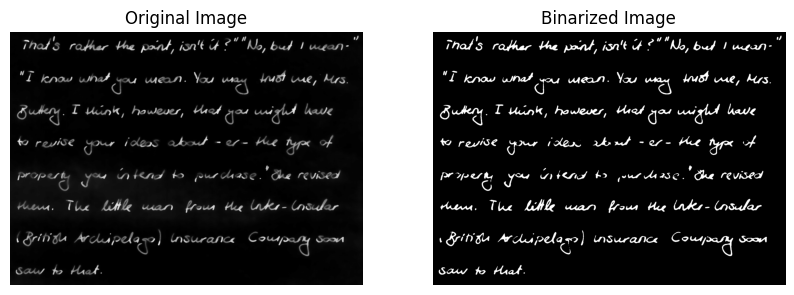

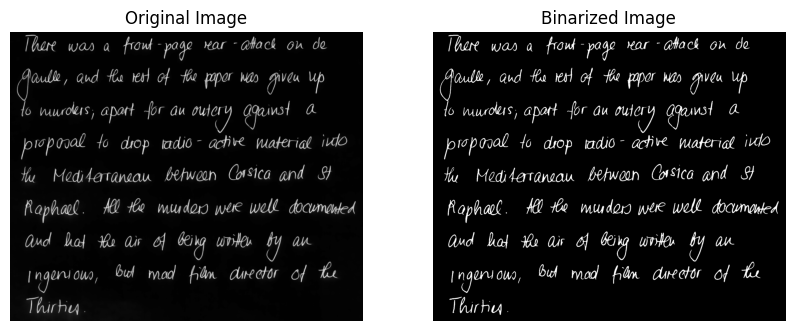

Binarized images saved to: /content/drive/MyDrive/IAMForms/cleanforms


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Input and output paths
input_path = "/content/drive/MyDrive/IAMForms/cleandata"
output_path = "/content/drive/MyDrive/IAMForms/cleanforms"
os.makedirs(output_path, exist_ok=True)  # Create output directory if it doesn't exist

# Process each image in the input directory
for filename in os.listdir(input_path):
    input_file_path = os.path.join(input_path, filename)

    # Check if the file is an image
    if not filename.endswith(('.png', '.jpg', '.jpeg', '.tif')):
        continue

    # Load image
    im = Image.open(input_file_path)
    np_img = np.array(im)

    # Convert to grayscale if necessary
    if len(np_img.shape) == 3:  # RGB image
        np_img = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)

    # Binarize the image using Otsu's thresholding
    _, binarized_img = cv2.threshold(np_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Save the binarized image
    output_file_path = os.path.join(output_path, f"binarized_{filename}")
    Image.fromarray(binarized_img).save(output_file_path)

    # Optionally, display the original and binarized images
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(np_img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Binarized Image")
    plt.imshow(binarized_img, cmap='gray')
    plt.axis('off')

    plt.show()

print(f"Binarized images saved to: {output_path}")


# SEGMENTATION - STAGE 1

Number of Contours found in binarized_denoised_final_1.png = 7


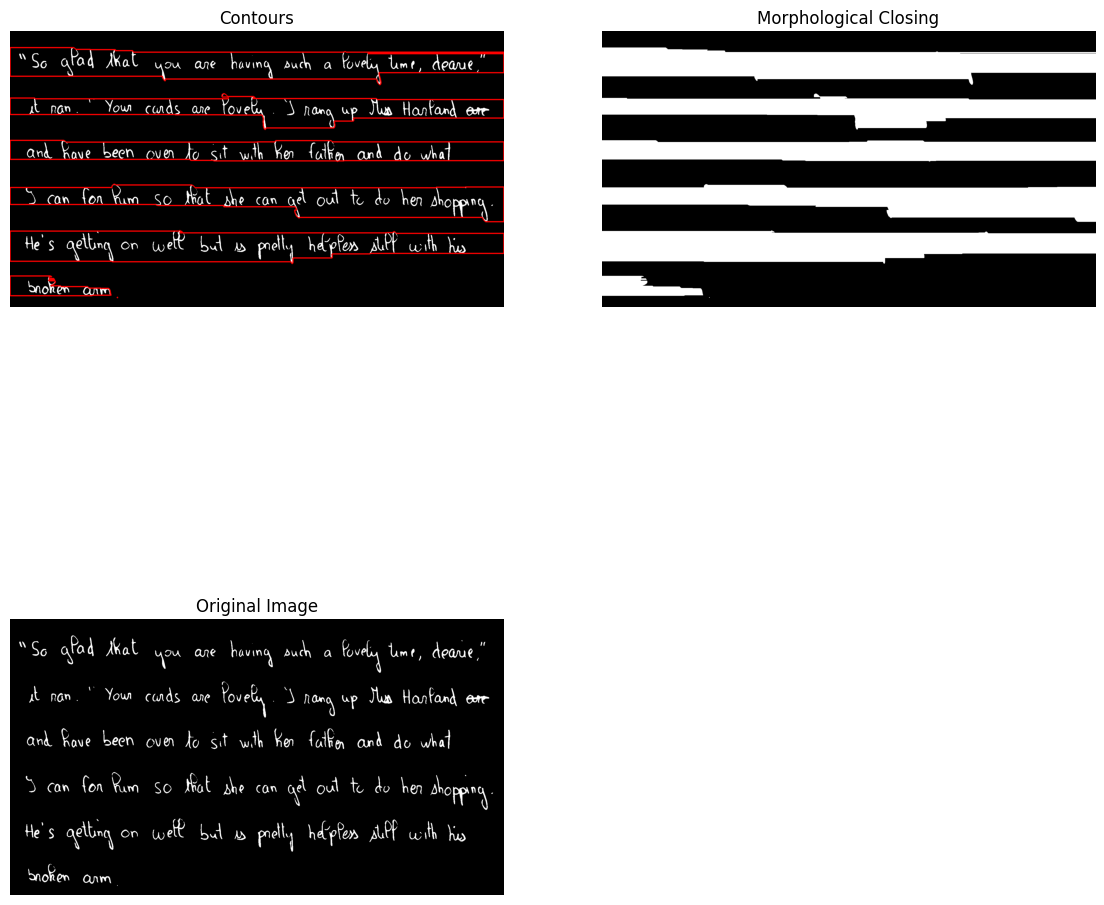

Number of Contours found in binarized_denoised_final_2.png = 9


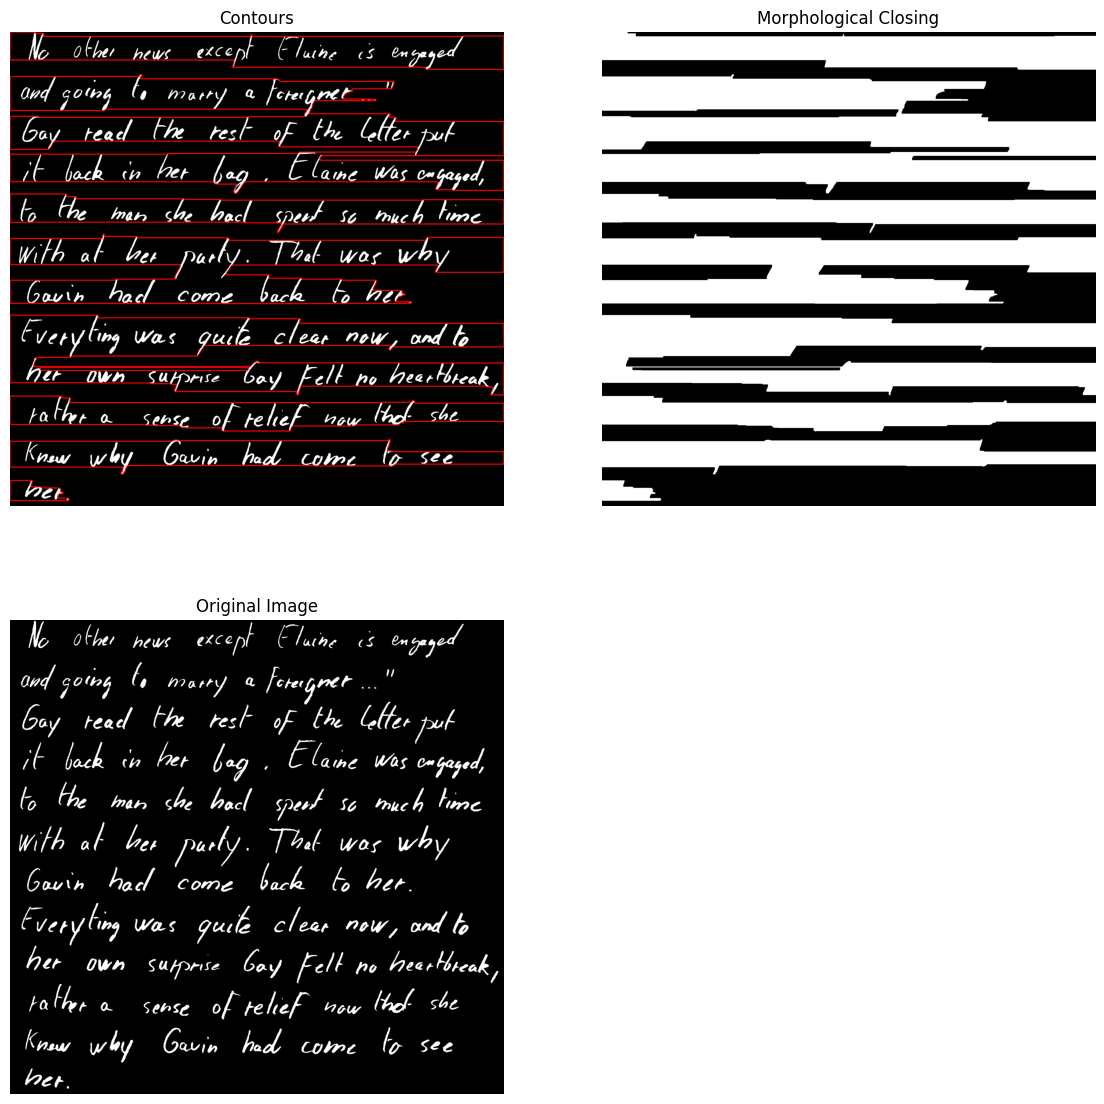

Number of Contours found in binarized_denoised_final_3.png = 14


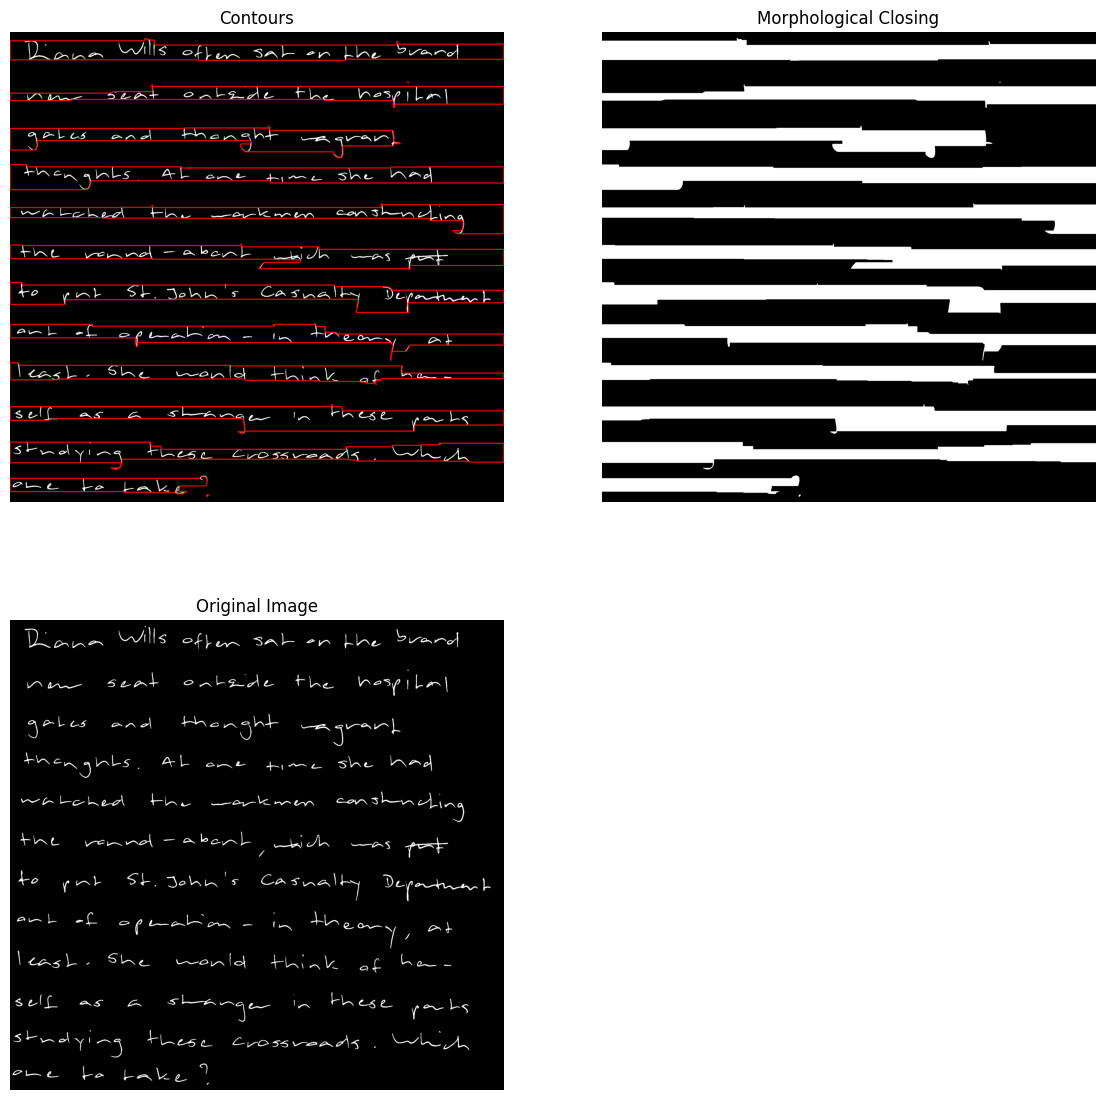

Number of Contours found in binarized_denoised_final_4.png = 5


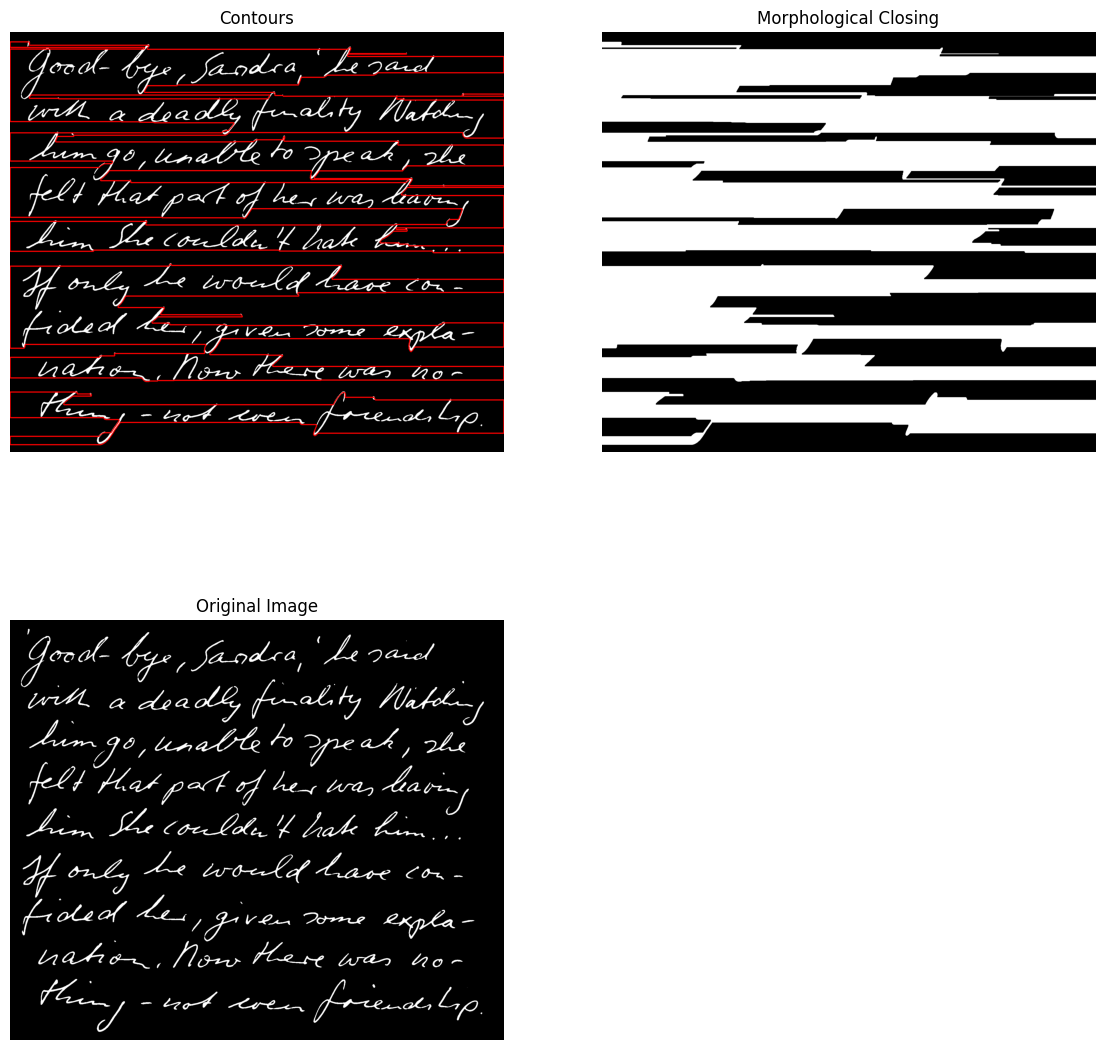

Number of Contours found in binarized_denoised_final_5.png = 6


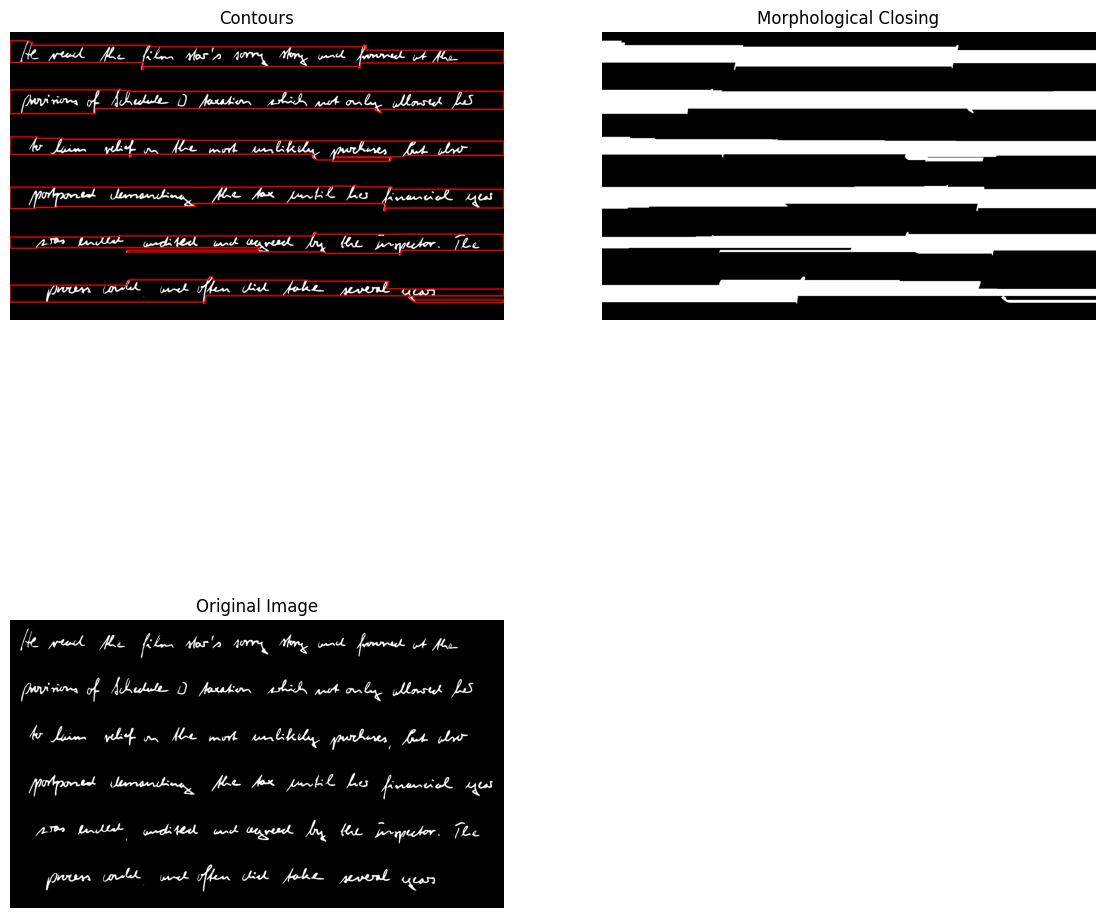

Number of Contours found in binarized_denoised_final_6.png = 7


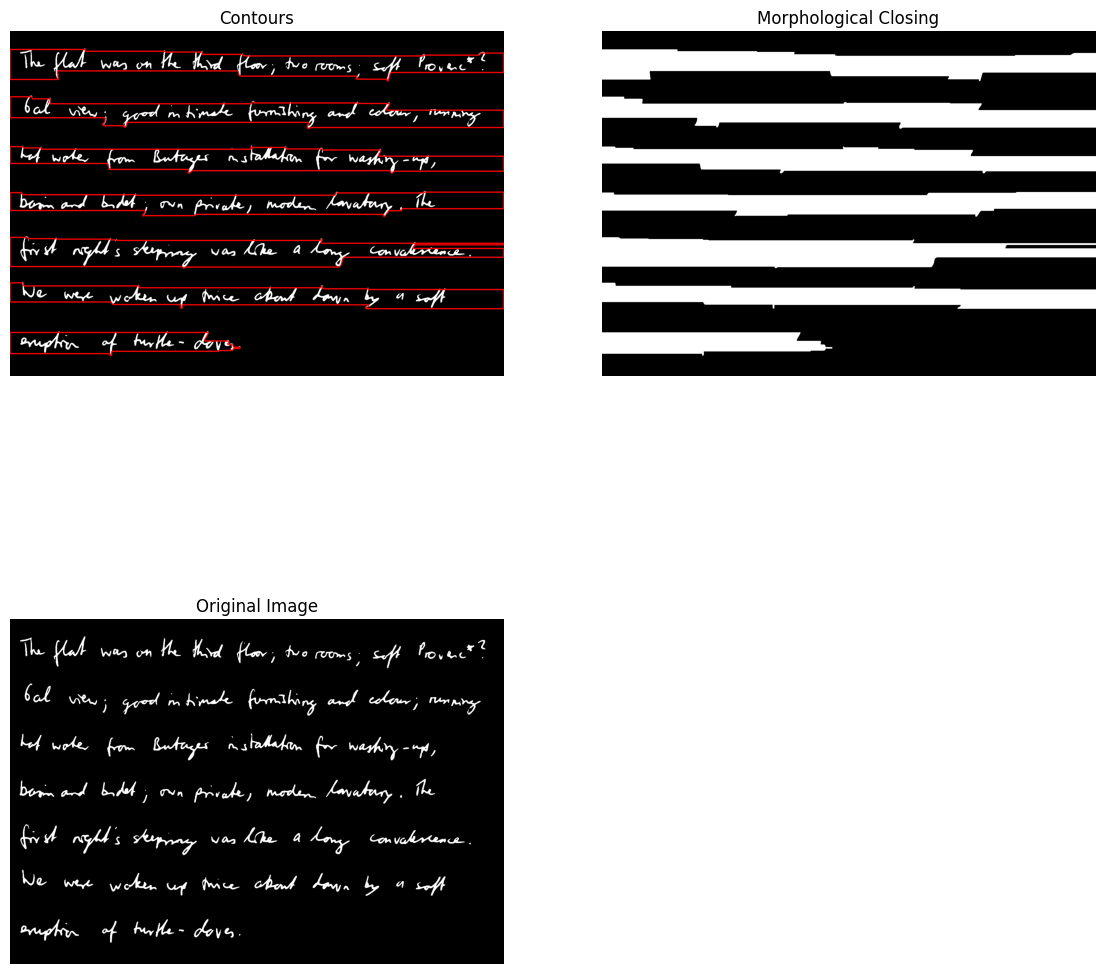

Number of Contours found in binarized_denoised_final_7.png = 8


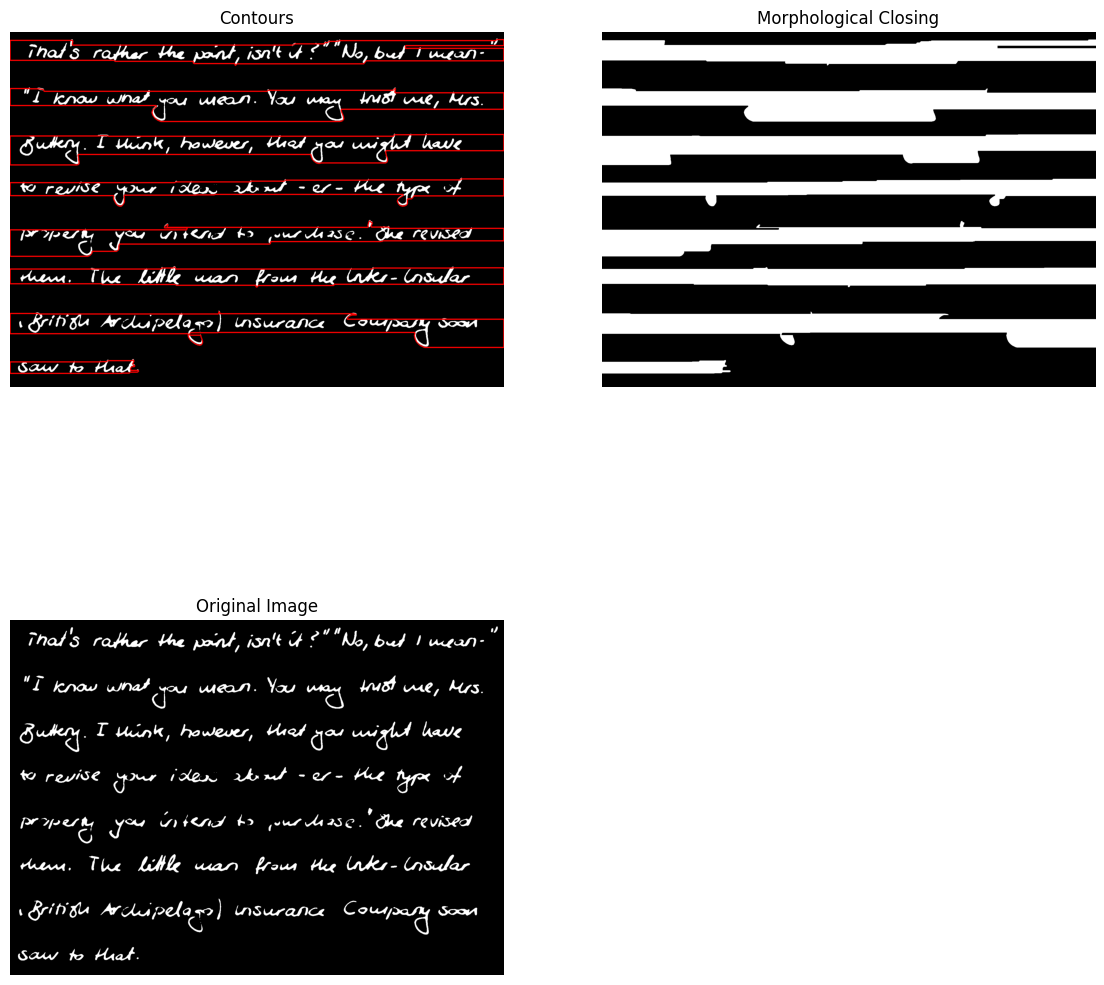

Number of Contours found in binarized_denoised_final_8.png = 8


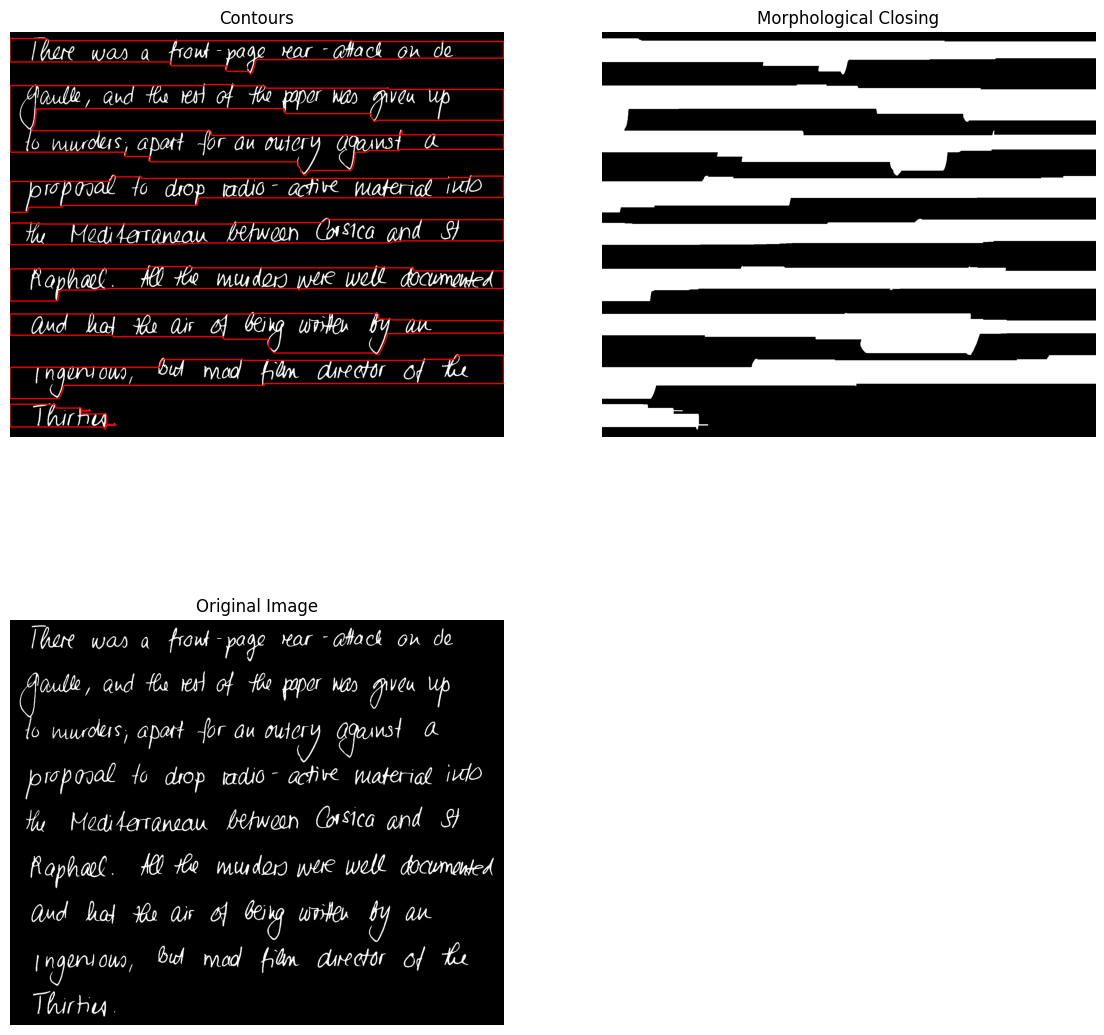

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Input path
input_path = "/content/drive/MyDrive/IAMForms/cleanforms"

# Process each image in the input directory
for filename in os.listdir(input_path):
    input_file_path = os.path.join(input_path, filename)

    # Check if the file is an image
    if not filename.endswith(('.png', '.jpg', '.jpeg', '.tif')):
        continue

    # Read the image
    ip = cv2.imread(input_file_path, cv2.IMREAD_GRAYSCALE)

    # Get image dimensions
    H, W = ip.shape[0:2]

    # Define morphological kernel
    kernel_height = H // 660
    kernel_width = W // 11  # Try with different values like 6, 10, or 11
    kernel = np.ones((kernel_height, kernel_width), np.uint8)

    # Convert image to float32
    ip_float = ip.astype(np.float32)

    # Morphological opening for noise removal
    opening = cv2.morphologyEx(ip_float, cv2.MORPH_OPEN, kernel, iterations=4)  # iterations chosen to obtain straight lines

    # Morphological closing
    closing = cv2.morphologyEx(ip_float, cv2.MORPH_CLOSE, kernel, iterations=4)

    # Convert the closed image to uint8 for contour detection
    im = closing.astype(np.uint8)

    # Find contours
    contours, hierarchy = cv2.findContours(im.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Convert the original grayscale image to RGB for visualization
    backtorgb = cv2.cvtColor(ip, cv2.COLOR_GRAY2RGB)

    # Draw contours on the color image
    cv2.drawContours(backtorgb, contours, -1, (255, 0, 0), 3)

    # Print the number of contours found
    print(f"Number of Contours found in {filename} = {len(contours)}")

    # Visualization
    plt.figure(figsize=(14, 14))

    # Contour visualization
    plt.subplot(2, 2, 1)
    plt.title("Contours")
    plt.imshow(backtorgb, cmap="gray")
    plt.axis("off")

    # Display the closing operation result
    plt.subplot(2, 2, 2)
    plt.title("Morphological Closing")
    plt.imshow(closing, cmap="gray")
    plt.axis("off")

    # Original image
    plt.subplot(2, 2, 3)
    plt.title("Original Image")
    plt.imshow(ip, cmap="gray")
    plt.axis("off")

    plt.show()


Number of Contours found = 8


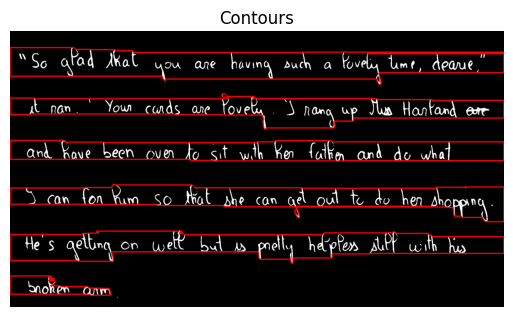

Number of Contours found = 10


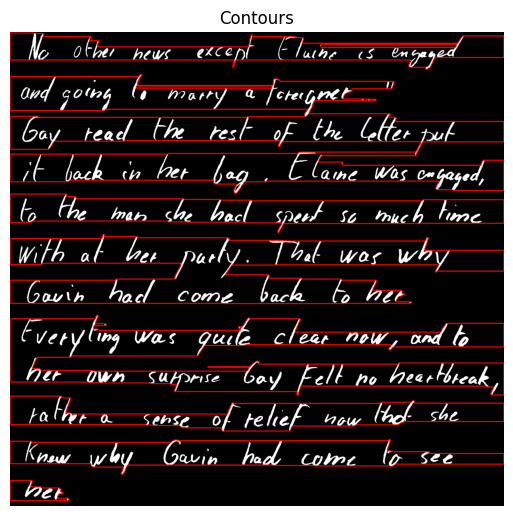

Number of Contours found = 16


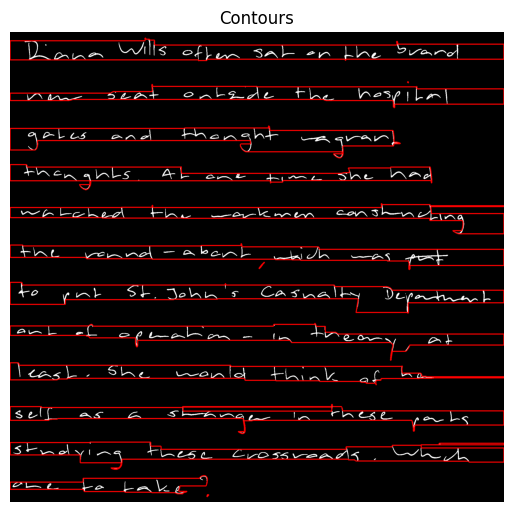

Number of Contours found = 5


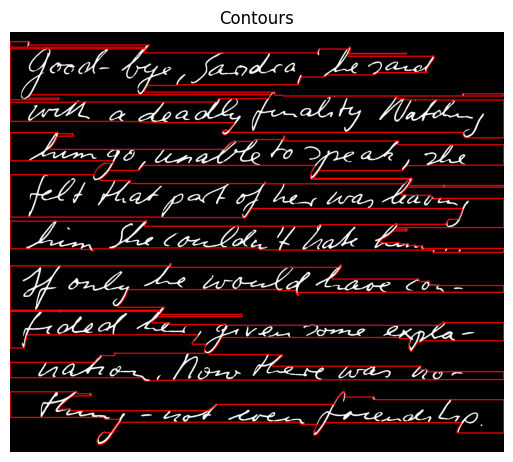

Number of Contours found = 8


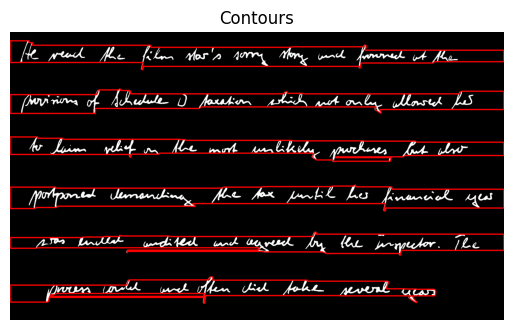

Number of Contours found = 7


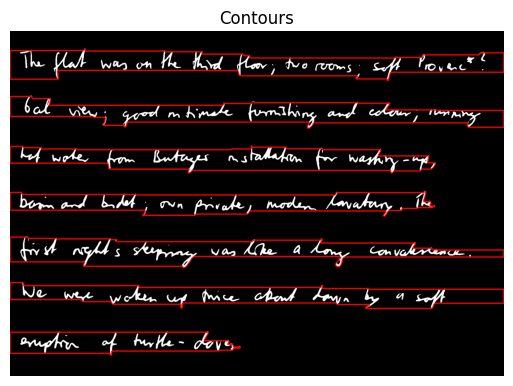

Number of Contours found = 9


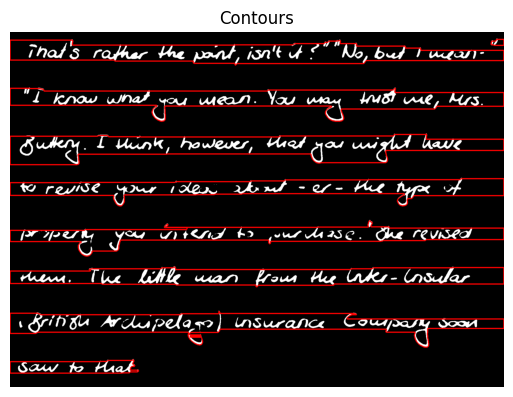

Number of Contours found = 8


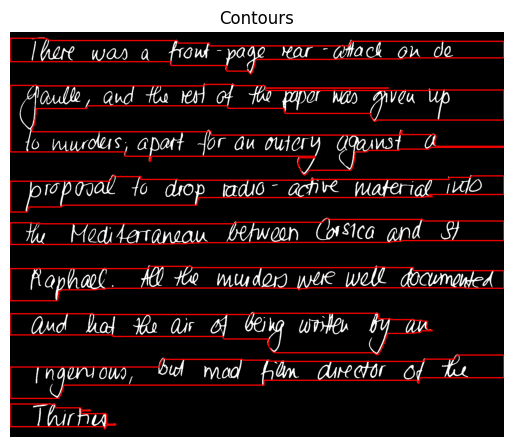

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from statistics import mean, stdev

# Initialize a list to store contours from all processed images
cnts_list = []

# Define the mask function
def mask(gray, roi_thresh, ctr, x, y, w, h):
    """
    Create a mask for a region of interest (ROI) and combine it with the thresholded ROI.
    Args:
        gray: Grayscale input image.
        roi_thresh: Thresholded region of interest.
        ctr: Contour coordinates.
        x, y, w, h: Bounding box of the ROI.
    Returns:
        roi_thresh: Combined ROI with the mask applied.
    """
    mask = ~np.zeros_like(gray)  # Create an inverted mask
    mask_cp = mask.astype(np.float32)
    roi_cp = roi_thresh.astype(np.float32)

    # Draw the contour on the mask
    cv2.drawContours(mask_cp, [ctr], 0, (0, 0, 0), -1)

    # Extract and combine the ROI
    roi_mask = mask[y:y+h, x:x+w]
    roi_cp = roi_cp.astype(np.uint8)
    roi_mask = roi_mask.astype(np.uint8)
    roi_thresh = cv2.bitwise_or(roi_mask, roi_cp)
    return roi_thresh

# Define the line segmentation function
def line_segmentation(input_image):
    """
    Perform line segmentation on the input image using morphological operations and contour detection.
    Args:
        input_image: Grayscale input image as a NumPy array.
    Returns:
        None. The function processes the image and stores contours for further use.
    """
    H, W = input_image.shape[0:2]

    # Define the morphological kernel
    kernel_height = H // 660
    kernel_width = W // 11
    kernel = np.ones((kernel_height, kernel_width), np.uint8)

    # Apply morphological closing
    ipf = input_image.astype(np.float32)
    closing = cv2.morphologyEx(ipf, cv2.MORPH_CLOSE, kernel, iterations=3)

    # Convert to uint8 for contour detection
    img = closing.astype(np.uint8)

    # Find contours
    cnts, hrc = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Convert the input image to RGB for visualization
    im_color = cv2.cvtColor(ipf.copy(), cv2.COLOR_GRAY2RGB)

    # Draw contours on the image
    cv2.drawContours(im_color, cnts, -1, (255, 0, 0), 3)

    # Store the contours in the global list
    cnts_list.append(cnts)

    # Print the number of contours detected
    print("Number of Contours found = " + str(len(cnts)))

    # Visualization
    plt.figure(figsize=(14, 14))
    plt.subplot(2, 2, 1)
    plt.title('Contours')
    plt.imshow(im_color, cmap='gray')
    plt.axis('off')


# Directory containing the input images
input_path = "/content/drive/MyDrive/IAMForms/cleanforms"

# Loop through each image in the directory
for filename in os.listdir(input_path):
    input_file_path = os.path.join(input_path, filename)

    # Skip non-image files
    if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
        continue

    # Read the image
    image = cv2.imread(input_file_path, cv2.IMREAD_GRAYSCALE)

    # Skip if the image couldn't be loaded
    if image is None:
        print(f"Unable to read the image: {filename}")
        continue

    # Apply line segmentation
    line_segmentation(image)

    # Show the results
    plt.show()



Here, it is observed some lines are appearing in addition, eventhough no text is present, hence we need to remove these lines

Number of Contours found = 7
Number of line contours: 7
x: 0 y: 65 w: 1949 h: 147


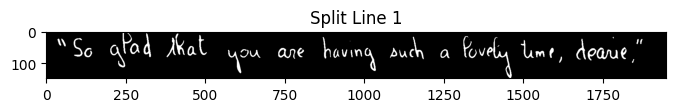

x: 0 y: 247 w: 1949 h: 142


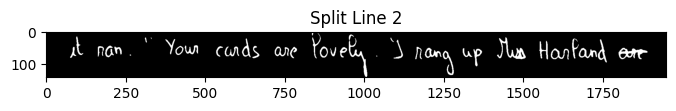

x: 0 y: 431 w: 1949 h: 84


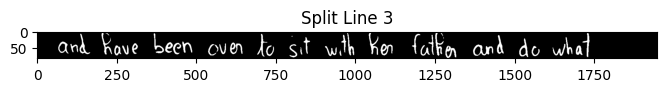

x: 0 y: 604 w: 1949 h: 149


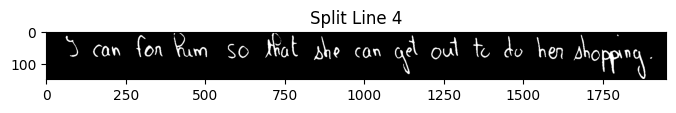

x: 0 y: 787 w: 1949 h: 131


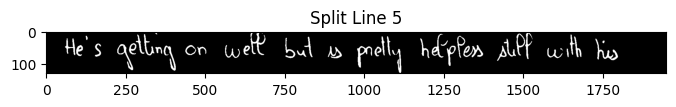

x: 0 y: 966 w: 399 h: 79


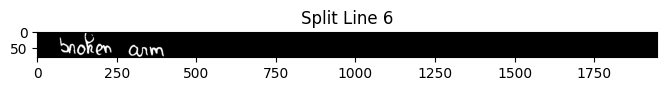

x: 0 y: 1050 w: 425 h: 3
avg height:  122
undersegmentation threshold:  176.9
6  ctr heights:  [147, 142, 84, 149, 131, 79]
Number of Contours found = 8
Number of line contours: 8
x: 0 y: 0 w: 2176 h: 166


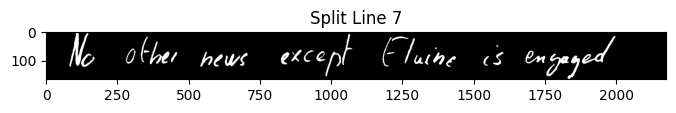

x: 0 y: 186 w: 2176 h: 526


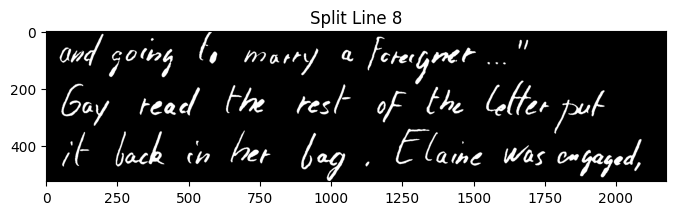

x: 0 y: 714 w: 2176 h: 172


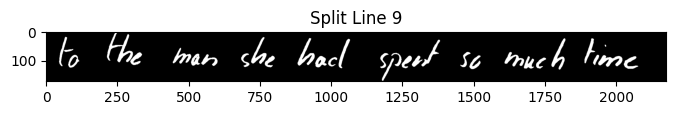

x: 0 y: 891 w: 2176 h: 307


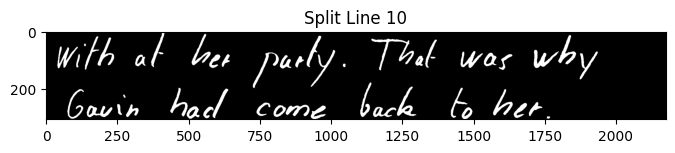

x: 0 y: 1248 w: 2176 h: 354


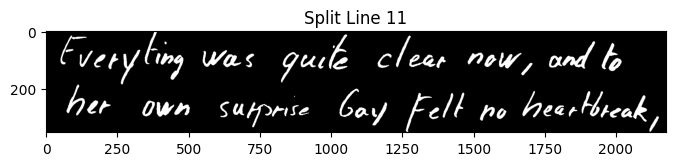

x: 0 y: 1605 w: 2176 h: 156


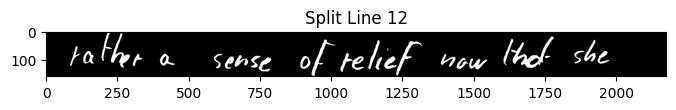

x: 0 y: 1796 w: 2176 h: 155


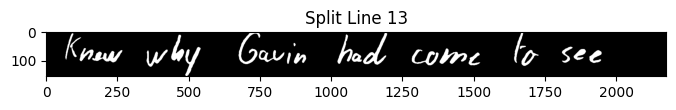

x: 0 y: 1977 w: 260 h: 90


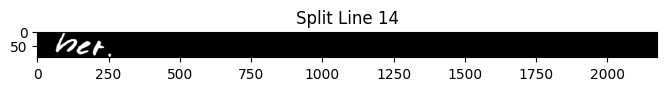

avg height:  240.75
undersegmentation threshold:  349.0875
8  ctr heights:  [166, 526, 172, 307, 354, 156, 155, 90]
Number of Contours found = 14
Number of line contours: 14
x: 0 y: 31 w: 2199 h: 102


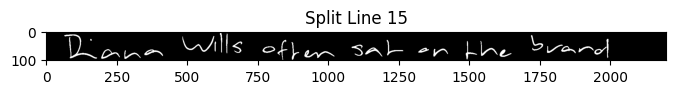

x: 1769 y: 225 w: 430 h: 6
x: 0 y: 237 w: 2199 h: 105


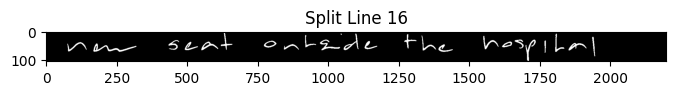

x: 0 y: 422 w: 2199 h: 143


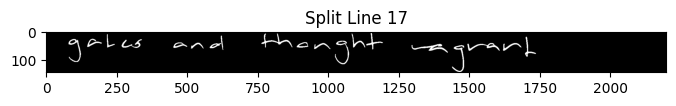

x: 0 y: 594 w: 2199 h: 113


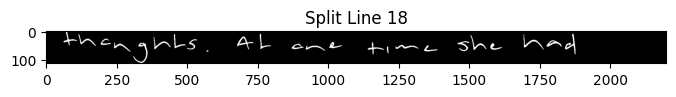

x: 0 y: 768 w: 2199 h: 135


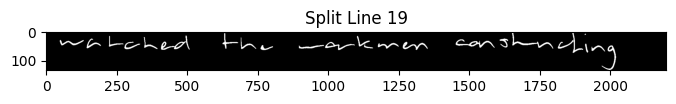

x: 0 y: 946 w: 2199 h: 116


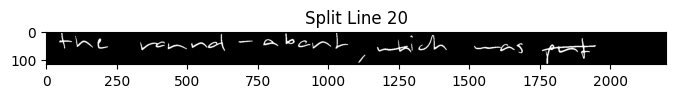

x: 0 y: 1118 w: 2199 h: 138


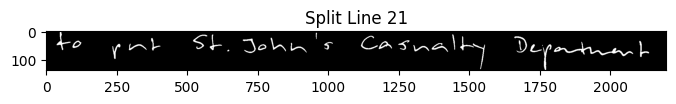

x: 0 y: 1300 w: 2199 h: 166


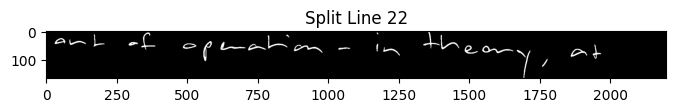

x: 0 y: 1476 w: 2199 h: 99


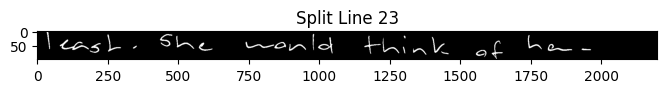

x: 0 y: 1661 w: 2199 h: 131


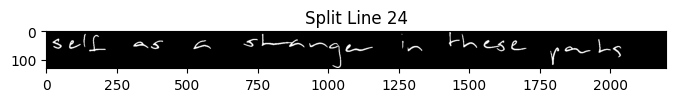

x: 0 y: 1829 w: 2199 h: 122


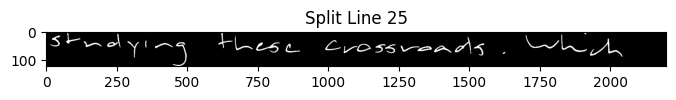

x: 0 y: 1978 w: 879 h: 82


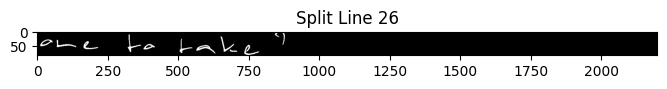

x: 876 y: 2063 w: 9 h: 10
avg height:  121
undersegmentation threshold:  175.45
12  ctr heights:  [102, 105, 143, 113, 135, 116, 138, 166, 99, 131, 122, 82]
Number of Contours found = 6
Number of line contours: 6
x: 0 y: 46 w: 2064 h: 882


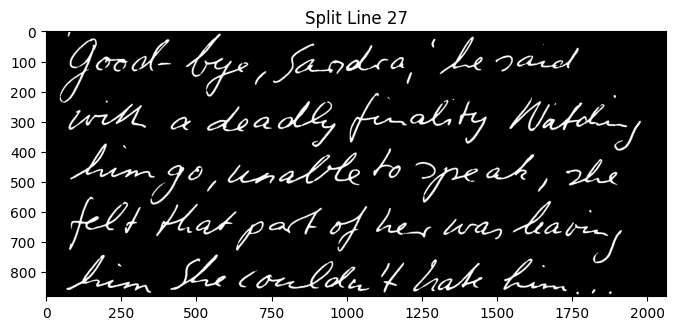

x: 81 y: 268 w: 1004 h: 15
x: 195 y: 425 w: 1698 h: 31
x: 504 y: 621 w: 1160 h: 14
x: 0 y: 975 w: 2064 h: 491


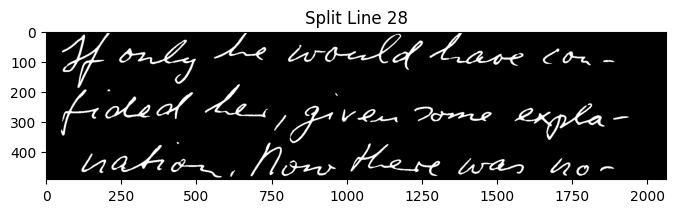

x: 0 y: 1509 w: 2064 h: 221


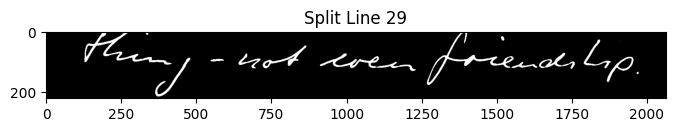

avg height:  531.3333333333334
undersegmentation threshold:  770.4333333333334
3  ctr heights:  [882, 491, 221]
Number of Contours found = 6
Number of line contours: 6
x: 0 y: 37 w: 1893 h: 112


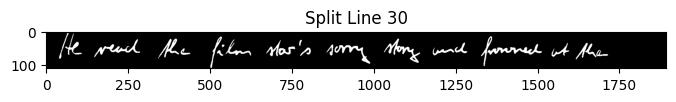

x: 0 y: 221 w: 1893 h: 96


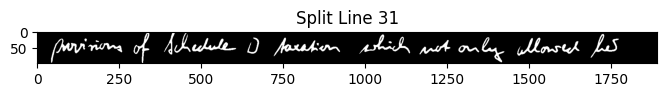

x: 0 y: 405 w: 1893 h: 96


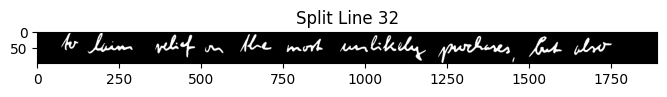

x: 0 y: 589 w: 1893 h: 101


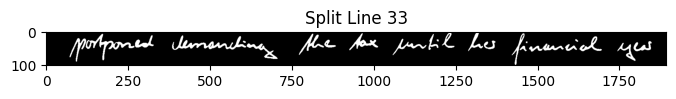

x: 0 y: 768 w: 1893 h: 91


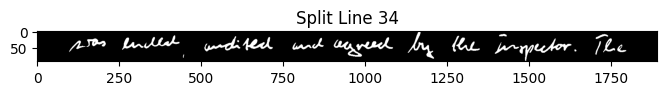

x: 0 y: 939 w: 1893 h: 104


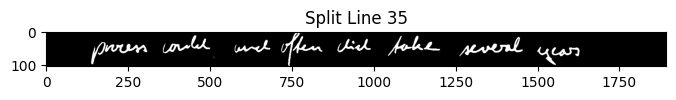

avg height:  100
undersegmentation threshold:  145.0
6  ctr heights:  [112, 96, 96, 101, 91, 104]
Number of Contours found = 7
Number of line contours: 7
x: 0 y: 72 w: 1911 h: 123


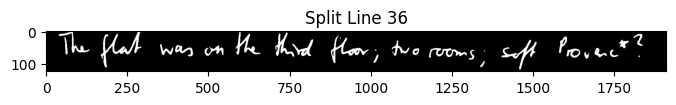

x: 0 y: 255 w: 1911 h: 124


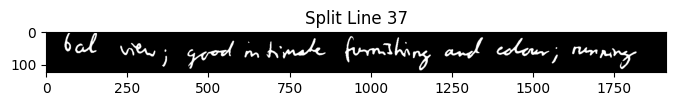

x: 0 y: 448 w: 1911 h: 104


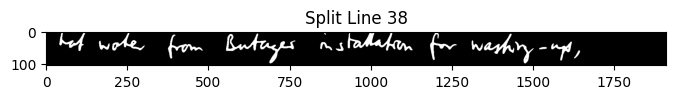

x: 0 y: 624 w: 1911 h: 96


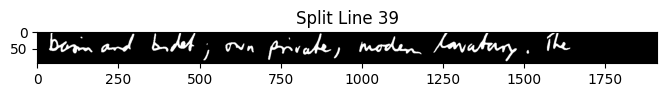

x: 0 y: 799 w: 1911 h: 120


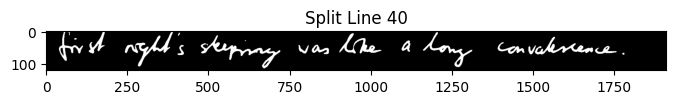

x: 0 y: 975 w: 1911 h: 101


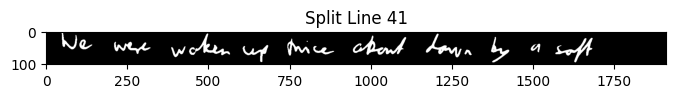

x: 0 y: 1166 w: 892 h: 92


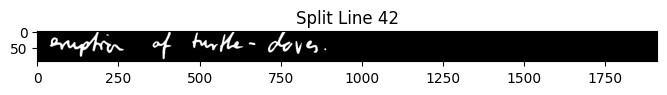

avg height:  108.57142857142857
undersegmentation threshold:  157.42857142857142
7  ctr heights:  [123, 124, 104, 96, 120, 101, 92]
Number of Contours found = 9
Number of line contours: 9
x: 0 y: 31 w: 1977 h: 104


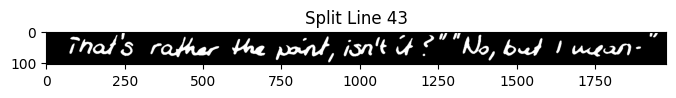

x: 0 y: 227 w: 1977 h: 133


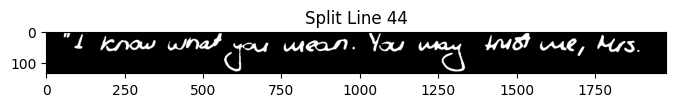

x: 0 y: 411 w: 1977 h: 123


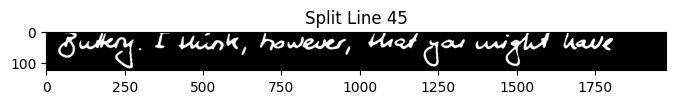

x: 0 y: 589 w: 1977 h: 110


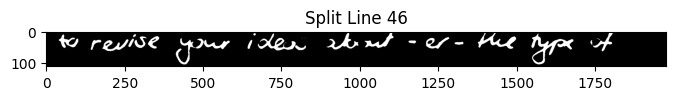

x: 0 y: 758 w: 1977 h: 142


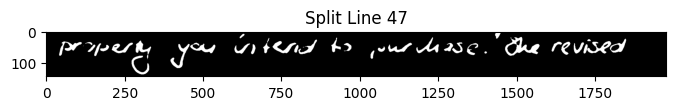

x: 0 y: 943 w: 1977 h: 80


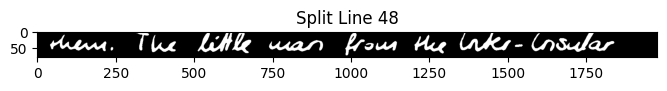

x: 0 y: 1121 w: 1977 h: 144


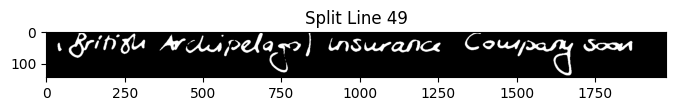

x: 719 y: 1205 w: 901 h: 11
x: 0 y: 1315 w: 515 h: 54


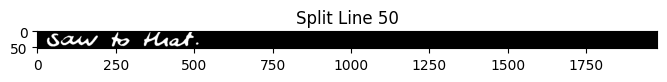

avg height:  111.25
undersegmentation threshold:  161.3125
8  ctr heights:  [104, 133, 123, 110, 142, 80, 144, 54]
Number of Contours found = 8
Number of line contours: 8
x: 0 y: 26 w: 1936 h: 142


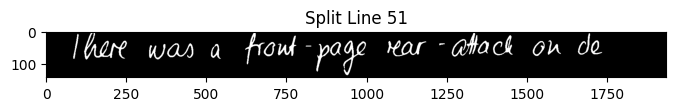

x: 0 y: 206 w: 1936 h: 358


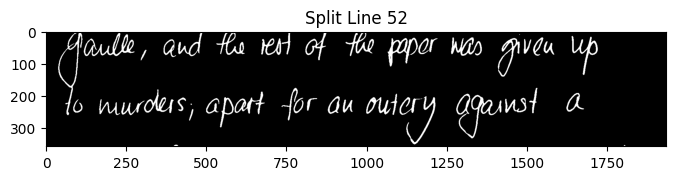

x: 0 y: 565 w: 1936 h: 144


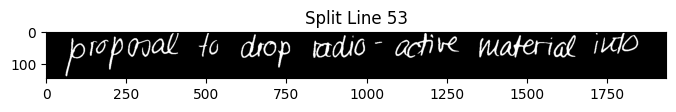

x: 0 y: 733 w: 1936 h: 103


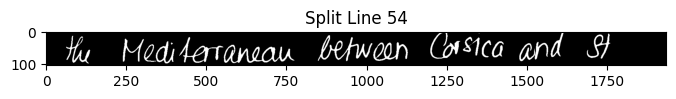

x: 0 y: 919 w: 1936 h: 138


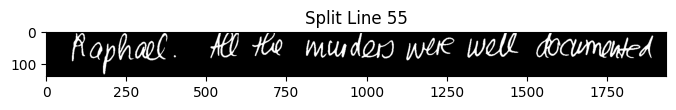

x: 0 y: 1103 w: 1936 h: 165


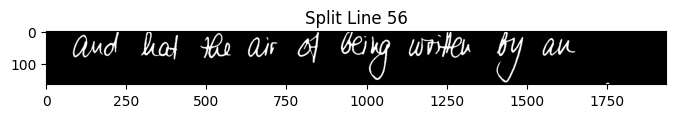

x: 0 y: 1269 w: 1936 h: 171


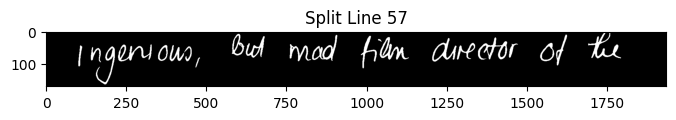

x: 0 y: 1461 w: 417 h: 100


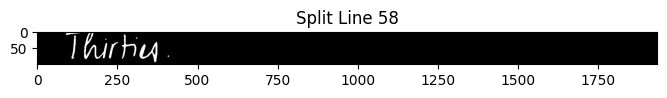

avg height:  165.125
undersegmentation threshold:  239.43125
8  ctr heights:  [142, 358, 144, 103, 138, 165, 171, 100]


In [ ]:
from PIL import Image  # Import the Image module from Pillow
import os
import cv2
import matplotlib.pyplot as plt
from statistics import mean

# Save function
def save(path, img):
    PATH = "/content/drive/MyDrive/IAMForms/"
    os.makedirs(os.path.dirname(PATH + path), exist_ok=True)  # Create the directory if it doesn't exist
    Image.fromarray(img).save(PATH + path)

# Function to split lines
def split_lines(image, x, y, w, h):
    split1 = image[y:y + h]
    return split1

# Line segmentation function
def line_seg(input_image, count):
    H, W = input_image.shape[0:2]
    kernel_height = H // 660
    kernel_width = W // 11
    kernel = np.ones((kernel_height, kernel_width), np.uint8)
    ipf = input_image.astype(np.float32)
    closing = cv2.morphologyEx(ipf, cv2.MORPH_CLOSE, kernel, iterations=5)
    img = closing.astype(np.uint8)
    cnts, hrc = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    im_color = cv2.cvtColor(ipf.copy(), cv2.COLOR_GRAY2RGB)

    print("Number of Contours found = " + str(len(cnts)))
    sorted_ctrs = sorted(cnts, key=lambda ctr: cv2.boundingRect(ctr)[1])
    print("Number of line contours:", len(sorted_ctrs))
    ctr_height = []  # To store height of each contour
    final_ctrs = []

    for i, ctr in enumerate(sorted_ctrs):
        x, y, w, h = cv2.boundingRect(ctr)
        print("x:", x, "y:", y, "w:", w, "h:", h)
        if w > input_image.shape[1] // 50 and h > input_image.shape[0] // 40:
            ctr_height.append(h)
            final_ctrs.append(ctr)

            split = split_lines(input_image, x, y, w, h)
            count += 1
            save("lines/line" + str(count) + ".jpg", split)

            # Create a new figure for each line to avoid subplot indexing issues
            plt.figure(figsize=(8, 4))
            plt.title(f'Split Line {count}')
            plt.imshow(split, cmap='gray')
            plt.show()


    avg_height = mean(ctr_height)

    print("avg height: ", avg_height)
    print("undersegmentation threshold: ", avg_height * 1.45)
    print(len(ctr_height), " ctr heights: ", ctr_height)
    cv2.drawContours(im_color, final_ctrs, -1, (255, 0, 0), 2)

    return count

# Directory containing the input images
input_path = "/content/drive/MyDrive/IAMForms/cleanforms"

# Initialize a counter
count = 0

# Loop through each image in the directory
for filename in os.listdir(input_path):
    input_file_path = os.path.join(input_path, filename)

    # Skip non-image files
    if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
        continue

    # Read the image
    image = cv2.imread(input_file_path, cv2.IMREAD_GRAYSCALE)

    # Skip if the image couldn't be loaded
    if image is None:
        print(f"Unable to read the image: {filename}")
        continue

    # Apply the line_seg function and update the count
    count = line_seg(image, count)

    # Show the results
    plt.show()


# Word Segmentation

In [ ]:
from PIL import Image  # Import the Image module from Pillow
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Save function
def save(path, img):
    PATH = "/content/drive/MyDrive/IAMForms/"
    os.makedirs(os.path.dirname(PATH + path), exist_ok=True)  # Create the directory if it doesn't exist
    Image.fromarray(img).save(PATH + path)

# Word segmentation function
def word_seg(line):
    global wcount
    kernel_height = 22
    kernel_width = line.shape[1] // 55  # Adjust kernel width based on line width
    kernel = np.ones((kernel_height, kernel_width), np.uint8)
    ipf = line.astype(np.float32)
    closing = cv2.morphologyEx(ipf, cv2.MORPH_CLOSE, kernel)
    img = closing.astype(np.uint8)
    cnts, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    print("Number of Contours found = " + str(len(cnts)))
    sorted_ctrs = sorted(cnts, key=lambda ctr: cv2.boundingRect(ctr)[0])  # Sort by x-coordinate
    print("Number of word contours:", len(sorted_ctrs))

    final_ctrs = []
    for i, ctr in enumerate(sorted_ctrs):
        x, y, w, h = cv2.boundingRect(ctr)
        roi = line[y:y + h, x:x + w]  # Region of interest

        print("Height: ", roi.shape[0], "Width: ", roi.shape[1])
        if roi.shape[0] < 50 or roi.shape[1] < 50:  # Ignore very small regions
            continue
        if roi.shape[1] > line.shape[1] // 50:  # Valid words based on width
            final_ctrs.append(ctr)
            print('Word segment no:', wcount)
            print("Location:\tx: ", x, "\ty: ", y)
            wcount += 1
            save("words/word" + str(wcount) + ".jpg", roi)

            # Display the segmented word
            plt.figure(figsize=(4, 4))
            plt.title(f'Word {wcount}')
            plt.imshow(roi, cmap='gray')
            plt.show()

# Directory containing the line images
PATH = "/content/drive/MyDrive/IAMForms/lines"

# Initialize a word count
wcount = 0

# Loop through each line image in the directory
for filename in os.listdir(PATH):
    line_file_path = os.path.join(PATH, filename)

    # Skip non-image files
    if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
        continue

    # Read the line image
    line_image = cv2.imread(line_file_path, cv2.IMREAD_GRAYSCALE)

    # Skip if the image couldn't be loaded
    if line_image is None:
        print(f"Unable to read the line image: {filename}")
        continue

    # Apply the word_seg function to the line image
    word_seg(line_image)


Output hidden; open in https://colab.research.google.com to view.

In [3]:
import os

def rename_files_in_order(path):
    # List all files in the directory
    files = sorted(os.listdir(path))

    # Initialize a counter for the new filenames
    counter = 1

    for file_name in files:
        # Construct the full file path
        full_path = os.path.join(path, file_name)

        # Check if it is a file (skip directories)
        if os.path.isfile(full_path):
            # Create a new filename with zero-padding (e.g., 0001)
            new_name = f"{counter:04}.png"  # Change the extension if needed

            # Construct the new file path
            new_full_path = os.path.join(path, new_name)

            # Rename the file
            os.rename(full_path, new_full_path)

            # Increment the counter
            counter += 1

    print(f"Renamed {counter - 1} files in {path}.")

# Path to the directory
path = "/content/drive/MyDrive/words/"

# Call the function
rename_files_in_order(path)


Renamed 325 files in /content/drive/MyDrive/words/.


In [4]:
import os
import shutil
import random

# Set the seed for reproducibility
random.seed(42)

# Paths
base_path = "/content/drive/MyDrive/words/"
train_path = os.path.join(base_path, "words_train")
test_path = os.path.join(base_path, "words_test")
val_path = os.path.join(base_path, "words_validation")

# Create directories if they don't exist
os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)

# Get all image files
image_files = [f for f in os.listdir(base_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Shuffle the files
random.shuffle(image_files)

# Calculate split indices
total_images = len(image_files)
train_size = int(0.7 * total_images)  # 70% training
val_size = int(0.15 * total_images)  # 15% validation
test_size = total_images - train_size - val_size  # Remaining for test

# Split the dataset
train_files = image_files[:train_size]
val_files = image_files[train_size:train_size + val_size]
test_files = image_files[train_size + val_size:]

# Function to move files
def move_files(file_list, destination):
    for file_name in file_list:
        src_path = os.path.join(base_path, file_name)
        dest_path = os.path.join(destination, file_name)
        shutil.move(src_path, dest_path)

# Move files to respective folders
move_files(train_files, train_path)
move_files(val_files, val_path)
move_files(test_files, test_path)

# Summary
print(f"Total images: {total_images}")
print(f"Training set: {len(train_files)} images")
print(f"Validation set: {len(val_files)} images")
print(f"Test set: {len(test_files)} images")


Total images: 325
Training set: 227 images
Validation set: 48 images
Test set: 50 images


In [10]:
!pip install opencv-python
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.9 MB/s eta 0:00:00


In [20]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define paths
image_dir = '/content/drive/MyDrive/words/words_test'
annotation_file = '/content/drive/MyDrive/words/words_test.txt'

# Get list of all PNG image files in the directory
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith('.png')]

# Open annotation file in write mode
with open(annotation_file, 'w') as f:
    # Iterate through each image
    for image_file in image_files:
        # Construct the full path to the image
        image_path = os.path.join(image_dir, image_file)

        try:
            # Open the image using PIL to ensure it's a valid PNG
            with Image.open(image_path) as img:
                # Display the image using matplotlib
                plt.imshow(img)
                plt.axis('off')  # Turn off axis
                plt.show()

                # Ask for user input (truth value)
                truth_value = input(f"Enter the truth value for {image_file} (text): ")

                # Write the filename and truth value to the annotation file
                f.write(f"{image_file}\t{truth_value}\n")

        except Exception as e:
            print(f"Skipping {image_file} due to error: {e}")
            continue  # Skip this file and move to the next one

print("Annotation file has been created successfully.")


Output hidden; open in https://colab.research.google.com to view.